In [ ]:
# Importações
import sys
import os
import pathlib
from pathlib import Path
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader, Subset
from datetime import timedelta
import matplotlib.pyplot as plt

# Detecção do root folder
notebook_path = pathlib.Path().absolute()
root_folder = notebook_path.parent

# Adicionar src ao path
SRC_DIR = root_folder
sys.path.append(str(SRC_DIR))

# Importar módulos do projeto
from src.utils.serialization import load_checkpoint
from src.utils.reprodutibility import set_seed
from src.utils.experiment_utils import find_experiment_by_name

# Importar as funções de plot
from src.result_analysis.plots import ( 
    plot_predictions_with_context,
    plot_metrics_by_horizon,
    plot_full_series_with_d1_forecast,
    plot_predictions_extremes,
    plot_metrics_by_horizon_comparison,
)

from src.result_analysis.extract_flow_extremes import analyze_flow_extremes

# Importar as funções de métricas
from src.result_analysis.metrics import (
    compute_flow_metrics,
    compute_metrics_by_event_type,
    print_metrics_summary,
)

from src import (
    ConfigLoader, load_feature_config, load_split_config, load_config,
    HydroDataset, create_dataset_for_training_validation, create_dataset_for_inference, create_temporal_split_with_gap,
    Seq2SeqHydro, train_model, predict_autoregressive,
    custom_collate_fn, get_device,
)

from src import save_predictions
from src.utils.experiment_utils import convert_predictions_to_df

# Configurações de caminhos
CONFIG_DIR = root_folder / "config"
DATA_DIR = root_folder / "data"
PROCESSED_DIR = DATA_DIR / "processed"
MODELS_DIR = root_folder / "models"

print(f"📁 Root folder: {root_folder}")
print(f"📁 Config: {CONFIG_DIR}")
print(f"📁 Processed data: {PROCESSED_DIR}")

In [2]:
# Carregar configurações
print("\n⚙️ Carregando configurações...")
data_config = load_config(CONFIG_DIR / "data_config.yaml")
model_config = load_config(CONFIG_DIR / "model_config.yaml")
train_config = load_config(CONFIG_DIR / "training_config.yaml")

# Extrair configurações
stations = data_config["stations"]
flow_window_config = data_config["flow_window_config"]
climate_window_config = data_config["climate_window_config"]
temporal_features = data_config["temporal_features"]
api_k_list = data_config["api_k_list"]
static_keys = data_config["static_keys"]
static_attributes_dict = data_config["static_attributes"]
window_stride = data_config['split_config']['window_stride']
train_ratio = data_config['split_config']['train_ratio']
test_ratio = data_config['split_config']['test_ratio']
val_ratio = data_config['split_config']['val_ratio']
horizon = data_config["horizon"]
reference_dates = data_config["reference_dates"]
experiment_name = data_config["experiment_name"]

print(f"✓ {len(stations)} estações carregadas")
print(f"✓ Configurações de modelo carregadas")
print(f"✓ Configurações de treino carregadas")
print(f"✓ Atributos estáticos de {len(static_attributes_dict)} estações carregados")


⚙️ Carregando configurações...
✓ 3 estações carregadas
✓ Configurações de modelo carregadas
✓ Configurações de treino carregadas
✓ Atributos estáticos de 3 estações carregados


In [3]:
# Célula 3: Carregar dados processados
print("\n📊 Carregando dados processados...")
features_file = PROCESSED_DIR / "features_combined.csv"

if not features_file.exists():
    raise FileNotFoundError(f"Arquivo de features não encontrado: {features_file}")

combined_df = pd.read_csv(features_file)
combined_df['date'] = pd.to_datetime(combined_df['date'])
combined_df = combined_df.set_index('date')

print(f"✓ Dados carregados: {len(combined_df)} dias")
print(f"  Período: {combined_df.index.min().date()} a {combined_df.index.max().date()}")
print(f"  Colunas: {len(combined_df.columns)}")


📊 Carregando dados processados...
✓ Dados carregados: 6330 dias
  Período: 1995-01-01 a 2012-04-30
  Colunas: 67


In [ ]:
## Caso queira passar manualmente o caminho para um modelo ## Se for modelo antigo deve ser usar load_checkpoint_legacy
#model_path = Path(r"C:/Users/emily/Documents/GitHub/Mini-curso-GitHub-Leo/outputs/experiments/exp_012_Improve_model_performance_climate_proj_fix_no_flow/model/model_climate_proj_fix.pth")

# Detecta automaticamente o último experimento pelo nome definido no data_config
exp_path = find_experiment_by_name(experiment_name)
model_dir = exp_path / "model"
pth_files = sorted(model_dir.glob("*.pth"))
if not pth_files:
    raise FileNotFoundError(f"Nenhum modelo encontrado em {model_dir}. Salve o modelo com save_checkpoint primeiro.")
model_path = pth_files[0]

# Configuração
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# 1. Carregar Modelo e Metadados
print(f"Carregando checkpoint: {model_path}")
model, meta = load_checkpoint(model_path, device=DEVICE)


Carregando checkpoint: C:\Users\emily\Documents\GitHub\Mini-curso-GitHub-Leo\outputs\experiments\exp_020_Improve_model_performance_revert_fix_scheduler\model\model_revert_fix_scheduler.pth
⚠️ Aviso: Carregamento seguro falhou (Weights only load failed. This file can still be loaded, to do so you have two options, do those steps only if you trust the source of the checkpoint. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL numpy._core.multiarray.scalar was not an allowed global by default. Please use `torch.serialization.add_safe_globals([numpy._core.multiarray.scalar

In [5]:
ds_full = create_dataset_for_training_validation(
    df=combined_df,
    stations=stations,
    static_attrs=static_attributes_dict,
    train_indices=np.array([0]),  # Dummy (será substituído)
    flow_window_config=flow_window_config,
    climate_window_config=climate_window_config,
    temporal_features=temporal_features,
    api_k_list=[],
    static_keys=static_keys,
    horizon=horizon,
    use_last_days_as_forecast=False,  # ✅ NÃO RESERVAR
    window_stride=1,  # ✅ SEMPRE 1 PARA TESTE/INFERÊNCIA
    forcings="P"
)

In [6]:
# 4. Injetar scalers do modelo treinado
ds_full.flow_scalers = meta["flow_scalers"]
ds_full.climate_scalers = meta["climate_scalers"]
ds_full.static_scalers = meta["static_scalers"]

print(f"📊 Dataset completo: {len(ds_full)} amostras")

train_ds, val_ds, test_ds = create_temporal_split_with_gap(
    dataset=ds_full,
    train_ratio=train_ratio,   # 95% treino
    val_ratio=val_ratio,    # 2.5% validação
    test_ratio=test_ratio,   # 2.5% teste
    gap=128
)

print(f"✂️ Split criado:")
print(f"  Validação/Teste: {len(test_ds)} amostras")

# 7. DataLoader
dl_test = DataLoader(
    test_ds,
    batch_size=64,
    shuffle=False,
    collate_fn=custom_collate_fn
)

print(f"✅ DataLoader criado com {len(dl_test)} batches")

📊 Dataset completo: 6286 amostras
✂️ Split criado:
  Validação/Teste: 315 amostras
✅ DataLoader criado com 5 batches


In [7]:
# 7. Executar Previsão
print("🔮 Gerando previsões")
preds, obs, baseline, g_seq, dates, _ = predict_autoregressive(
    model=model,
    loader=dl_test, # Agora carrega apenas o teste
    decoder_history=meta["decoder_history"],
    decoder_horizon=meta["decoder_horizon"],
    scalers=meta["flow_scalers"],
    stations=data_config["stations"],
    clamp_non_negative=True,
    device=DEVICE)

🔮 Gerando previsões


In [ ]:
# Métricas Gerais (salva automaticamente na pasta do último experimento)
metrics = compute_flow_metrics(
    preds=preds,
    obs=obs,
    stations=meta["stations"],
    baseline_last=baseline,
    save=True,
    mode="test",
)

print_metrics_summary(metrics)

### Diagnóstico

delta: mean=0.0051  std=0.0211  %neg=33.3%  %pos=66.7%
gate:  mean=0.319  min=0.256  max=0.350


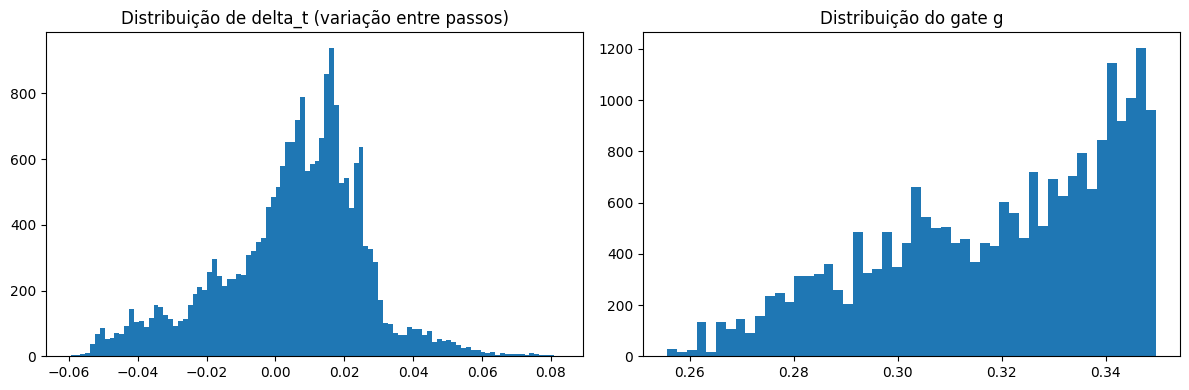

In [ ]:
### Avaliando deltas e gates

from src.utils.data_utils import move_sample_to_device
# Criar loader temporário para diagnóstico
from torch.utils.data import DataLoader

diag_loader = DataLoader(
    val_ds,
    batch_size=64,
    shuffle=False,
    collate_fn=custom_collate_fn
)

model.eval()
all_deltas = []
all_gates = []

with torch.no_grad():
    for batch in diag_loader:
        b = move_sample_to_device(batch, DEVICE)
        preds, mask, g_seq = model(b, 0.0, meta["decoder_history"], meta["decoder_horizon"])
        
        # Delta real: variação entre passos consecutivos das previsões
        delta = preds[:, 1:, :] - preds[:, :-1, :]
        all_deltas.append(delta.cpu().numpy())
        
        if g_seq is not None:
            all_gates.append(g_seq.cpu().numpy())

deltas = np.concatenate(all_deltas).flatten()
gates  = np.concatenate(all_gates).flatten()

print(f"delta: mean={deltas.mean():.4f}  std={deltas.std():.4f}  "
      f"%neg={(deltas<0).mean()*100:.1f}%  %pos={(deltas>0).mean()*100:.1f}%")
print(f"gate:  mean={gates.mean():.3f}  min={gates.min():.3f}  max={gates.max():.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(deltas, bins=100)
axes[0].set_title("Distribuição de delta_t (variação entre passos)")
axes[1].hist(gates, bins=50)
axes[1].set_title("Distribuição do gate g")
plt.tight_layout()

In [9]:
# Diagnostico interno: decomposicao delta_lstm, delta_climate, gate por step
import sys

# Para Jupyter/Spyder no Windows, apenas definir encoding nas impressões
# não tente recriar o stdout, pois não funciona nesses ambientes

from src.utils.data_utils import move_sample_to_device

# Usar primeira amostra do teste (ou val_ds para comparar)
sample = test_ds[0]
batch = custom_collate_fn([sample])
batch = move_sample_to_device(batch, DEVICE)

model.eval()
with torch.no_grad():
    preds_diag, diag = model.diagnostic_forward(
        batch, meta["decoder_history"], meta["decoder_horizon"]
    )

# Imprimir decomposicao por estacao
for st_idx, st in enumerate(stations):
    scaler = meta["flow_scalers"][f"Q_{st}"]
    print(f"\n{'='*80}")
    print(f"  Estacao {st}")
    print(f"{'='*80}")
    print(f"  {'t':>3s} | {'delta_lstm':>11s} {'delta_clim':>11s} {'delta_total':>11s} | "
          f"{'gate':>6s} | {'y_prev':>10s} {'pred':>10s} {'diff':>10s}")
    print(f"  {'-'*3}-+-{'-'*11}-{'-'*11}-{'-'*11}-+-{'-'*6}-+-{'-'*10}-{'-'*10}-{'-'*10}")

    for t in range(meta["decoder_horizon"]):
        #dl = diag['delta_lstm'][t][0, st_idx].item()
        #dc = diag['delta_climate'][t][0, st_idx].item()
        dt = diag['delta_total'][t][0, st_idx].item()
        g = diag['gate'][t][0, st_idx].item()
        yp_scaled = diag['y_prev'][t][0, st_idx].item()
        pr_scaled = diag['pred'][t][0, st_idx].item()
        yp = scaler.inverse_transform(torch.tensor(yp_scaled)).item()
        pr = scaler.inverse_transform(torch.tensor(pr_scaled)).item()
        diff = pr - yp
        #print(f"  {t:3d} | {dl:+11.4f} {dc:+11.4f} {dt:+11.4f} | "
        print(f"  {t:3d} | {dt:+11.4f} | "
              f"{g:6.3f} | {yp:10.0f} {pr:10.0f} {diff:+10.0f}")

    print(f"\n  Resumo: ext_features mean={diag['ext_features_mean'][0][0].item():.3f}, "
          f"std={diag['ext_features_std'][0][0].item():.3f}")


  Estacao 10100000
    t |  delta_lstm  delta_clim delta_total |   gate |     y_prev       pred       diff
  ----+-------------------------------------+--------+---------------------------------
    0 |     -0.0556 |  0.288 |      50516      50052       -465
    1 |     -0.0570 |  0.307 |      50052      49589       -463
    2 |     -0.0561 |  0.305 |      49589      49131       -458
    3 |     -0.0504 |  0.297 |      49131      48715       -416
    4 |     -0.0390 |  0.331 |      48715      48409       -306
    5 |     -0.0324 |  0.322 |      48409      48152       -257
    6 |     -0.0281 |  0.280 |      48152      47914       -237
    7 |     -0.0255 |  0.291 |      47914      47702       -212
    8 |     -0.0257 |  0.312 |      47702      47494       -208
    9 |     -0.0260 |  0.325 |      47494      47288       -206
   10 |     -0.0230 |  0.312 |      47288      47103       -186
   11 |     -0.0155 |  0.337 |      47103      46982       -121
   12 |     -0.0127 |  0.329 |      

### Métricas

In [ ]:
# Métricas por evento (salva automaticamente)
thresholds, classifications, window_indices = analyze_flow_extremes(
    df=combined_df,
    stations=stations,
    window_dates=dates,
    flow_col_pattern="Q_{}"
)

metrics_by_event = compute_metrics_by_event_type(
    preds=preds,
    obs=obs,
    stations=stations,
    window_indices=window_indices,
    baseline_last=baseline,
    horizon_weights=None,
    save=True,
    mode="test",
    filename_base="metrics_by_event",
)

In [ ]:
# --- CONFIGURAÇÕES ---
MODE = "test"  # ou "operational"

# 1. Métricas por Horizonte (salva automaticamente)
fig_metrics = plot_metrics_by_horizon(
    metrics, stations,
    save=True, show=False, mode=MODE,
)

# 2. Série Temporal D+1 (salva automaticamente)
fig_series = plot_full_series_with_d1_forecast(
    preds=preds, obs=obs, stations=stations,
    forecast_dates=dates, df=combined_df,
    period_name=MODE, baseline_last=baseline,
    figsize=(16, 5),
    save=True, show=False, mode=MODE,
)

# 3. Todas as janelas de previsão com contexto (salva automaticamente)
figs_context = plot_predictions_with_context(
    preds, obs, stations, combined_df, dates,
    context_days=30,
    baseline_last=baseline,
    g_seq=g_seq,
    save=True, show=False, mode=MODE,
)
for fig in figs_context:
    plt.close(fig)

'''
# 4. Eventos Extremos (salva automaticamente)
figs_extremes = plot_predictions_extremes(
    preds, obs, stations, combined_df, dates,
    n_samples=5, extreme_type='max',
    save=True, show=False, mode=MODE,
)
for fig in figs_extremes:
    plt.close(fig)
'''